# **Data Quality Validation v4**
### **Objective:** Quantitative proof of Feature Engineering ROI via Mutual Information and PCA Analysis.

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

def encode_df(df):
    df_enc = df.copy()
    le = LabelEncoder()
    for col in df_enc.select_dtypes(include=['object']).columns:
        df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    return df_enc

old_dataset = 'Dataset/raw_data.csv'
new_dataset = 'Dataset/GOLD_STANDARD_DATASET.csv'

df_raw_enc = encode_df(pd.read_csv(old_dataset).drop(columns=['order_id'], errors='ignore'))
df_feat_enc = encode_df(pd.read_csv(new_dataset).drop(columns=['order_id'], errors='ignore'))

## **STEP 1: Mutual Information (MI) Comparison**
Quantifying non-linear predictive power gain.

In [4]:
X_raw = df_raw_enc.drop('delivery_time_hours', axis=1)
y_raw = df_raw_enc['delivery_time_hours']
X_feat = df_feat_enc.drop('delivery_time_hours', axis=1)
y_feat = df_feat_enc['delivery_time_hours']

mi_raw = mutual_info_regression(X_raw.sample(69000), y_raw.sample(69000)).sum()
mi_feat = mutual_info_regression(X_feat.sample(69000), y_feat.sample(69000)).sum()

print(f"Total Information Score of {old_dataset}: {mi_raw:.3f}")
print(f"Total Information Score of {new_dataset} :  {mi_feat:.3f}")
print(f"📈 Information Density Increase: {((mi_feat/mi_raw)-1)*100:.2f}%")

Total Information Score of Dataset/raw_data.csv: 0.014
Total Information Score of Dataset/GOLD_STANDARD_DATASET.csv :  0.020
📈 Information Density Increase: 50.44%


## **STEP 2: Manifold Analysis (PCA)**
Visualizing how the feature space 'unfolds' the target variable.

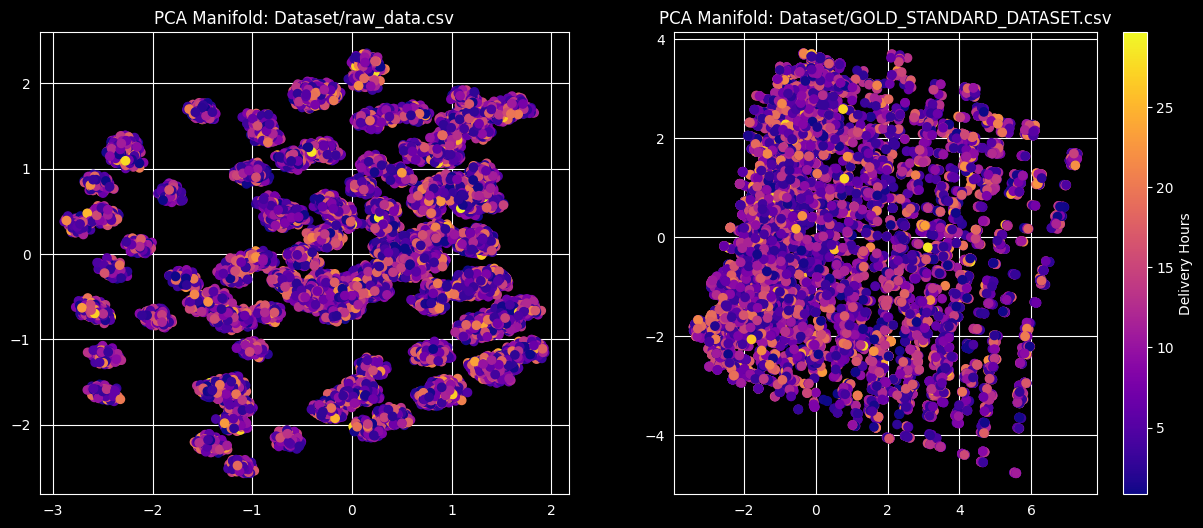

In [5]:
scaler = StandardScaler()
pca = PCA(n_components=2)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for i, (data, label) in enumerate(zip([X_raw, X_feat], [old_dataset, new_dataset])):
    comp = pca.fit_transform(scaler.fit_transform(data.sample(20000)))
    im = ax[i].scatter(comp[:,0], comp[:,1], c=y_feat.sample(20000), cmap='plasma')
    ax[i].set_title(f"PCA Manifold: {label}")

plt.colorbar(im, ax=ax[1], label='Delivery Hours')
plt.show()